<center>
<h2>Cinemática Inversa de manipuladores utilizando el método de Newton-Raphson</h2>
<font color="#127A69" size="3">
Universidad Politécnica de Guanajuato <br>
Departamento de Ingeniería Robótica <br>
Fundamentos de Robótica (Mayo-Agosto 2018)
</font><br><br>
    <i><b>M.C. Pedro Jorge De Los Santos Lara</b></i>
</center>

En lo subsiguiente se describen los aspectos básicos para realizar un análisis cinemático inverso utilizando el método de Newton-Raphson para la solución de sistemas de ecuaciones no lineales resultantes del cálculo de la cinemática directa.

Se comenzará importando las librerías/módulos a utilizar y definiendo algunas funciones útiles para el desarrollo posterior.

In [13]:
from sympy import * # Librería de CAS
from sympy.matrices import * # Módulo de matrices de SymPy
init_printing(use_latex=true) # Usando el modo "pretty print" + LaTeX

def newton_raphson(J,b,X0,vals={},eps=1e-5):
    """
    Resuelve un sistema de ecuaciones no lineales utilizando el método de Newton-Raphson.
    Parámetros de entrada:
    
    J - Matriz jacobiana
    b - -(Vector de ecuaciones)
    X0 - Valores iniciales propuestos
    vals - Valores adicionales
    eps - tolerancia numérica predefinida
    """
    k = 1
    b = b.subs(vals).evalf()
    while True:
        x = ((J.subs(X0).subs(vals)).inv()*b.subs(X0)).evalf()
        if x.norm()<eps: break
        for jj,ky in enumerate(X0):
            X0[ky] += (x[jj]).evalf()
        k += 1
    return X0,x,k

def dh(a,alpha,d,theta):
    """
    Calcula la matriz de Denavit-Hartenberg dados los parámetros correspondientes.
    """
    M = Matrix([[cos(theta),-sin(theta)*cos(alpha),sin(theta)*sin(alpha),a*cos(theta)],
                  [sin(theta),cos(theta)*cos(alpha),-cos(theta)*sin(alpha),a*sin(theta)],
                  [0,sin(alpha),cos(alpha),d],
                  [0,0,0,1]])
    return M

rad = lambda x: (x*pi/180).evalf()
deg = lambda x: (x*180/pi).evalf()

## Ejemplo 1. Manipulador planar RR

Se tiene un manipulador planar RR cuyas dimensiones son $L_1 = L_2 = 100$ mm y se requiere calcular los valores de $\theta_1$ y $\theta_2$ para posicionar su extremo en las coordenadas $(110,90)$.

La matriz de transformación homogénea que relaciona el extremo con la base está dada por:

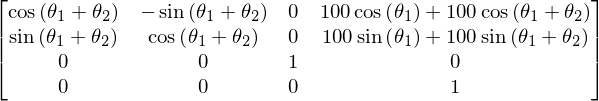

In [14]:
l1,l2 = 100,100
t1,t2 = symbols('\\theta_1,\\theta_2')
A1 = dh(l1,0,0,t1)
A2 = dh(l2,0,0,t2) 
T = simplify(A1*A2)
T

Entonces las ecuaciones no lineales a resolver deberán formularse como:

In [15]:
px,py = 110,90
f1 = T[0,3] - px
f2 = T[1,3] - py
f1,f2

Luego, se debe calcular la matriz Jacobiana a partir del vector de ecuaciones:

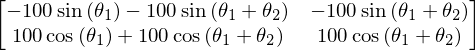

In [16]:
f = Matrix([f1,f2]) # Vector de ecuaciones
J = f.jacobian([t1,t2]) # Matriz jacobiana
J

Una vez se tiene la matriz jacobiana y el vector de ecuaciones, se procede a definir los valores iniciales propuestos y se *llama* a la función encargada de ejecutar el método de Newton-Raphson:

In [22]:
X0 = {t1:pi/3, t2:pi/3} # Valores iniciales propuestos
XS,x,k = newton_raphson(J,-f,X0)

La solución está dada por:

In [23]:
deg(XS[t1]), deg(XS[t2])

El número de iteraciones realizadas:

In [24]:
k

Evidentemente es esperable que si los valores iniciales son bastante aproximados el número de iteraciones se reducirá, por ejemplo:

In [38]:
X0 = {t1:rad(0), t2:rad(90)} # Valores iniciales propuestos
XS,x,k = newton_raphson(J,-f,X0)
deg(XS[t1]), deg(XS[t2]), k